# Titanic Dataset Analysis

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

In [53]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
df.shape

(891, 12)

In [55]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Univariate Analysis --- one variable at a time

## Numerical --> histogramn, histogram with kde, boxplot , kde only and line plot ( only for time series data or sequential data)

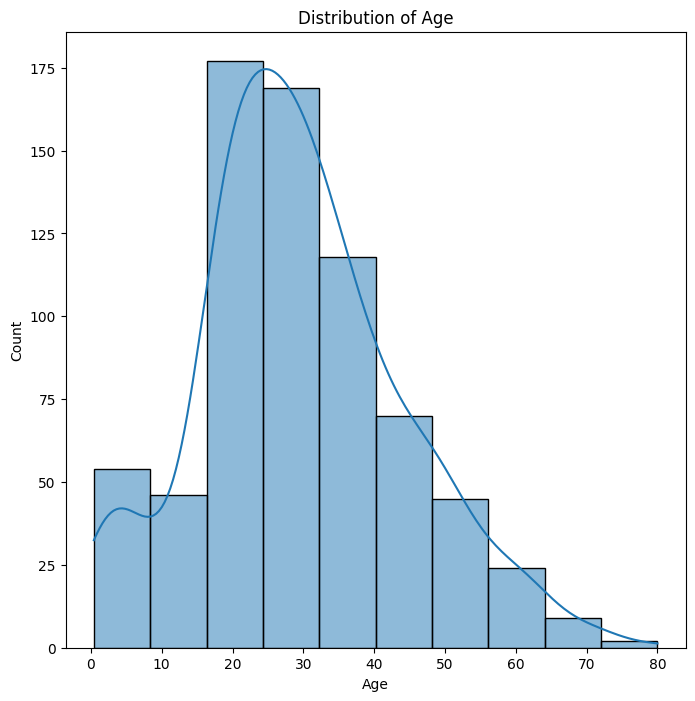

In [56]:
plt.figure(figsize = (8,8))
sns.histplot(df['Age'],bins=10, kde=True)
plt.title("Distribution of Age")
plt.show()

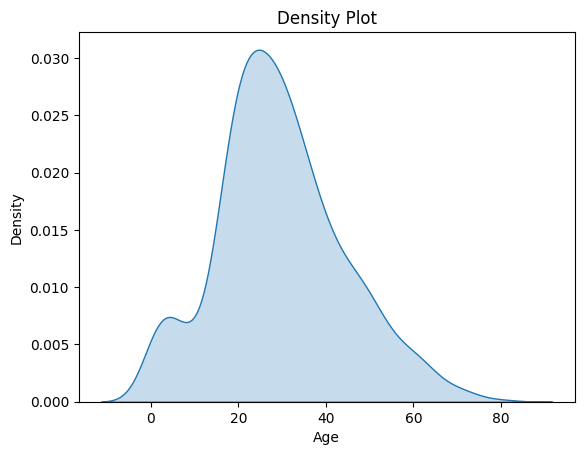

In [57]:
sns.kdeplot(df['Age'],fill=True)
plt.title("Density Plot")
plt.show()

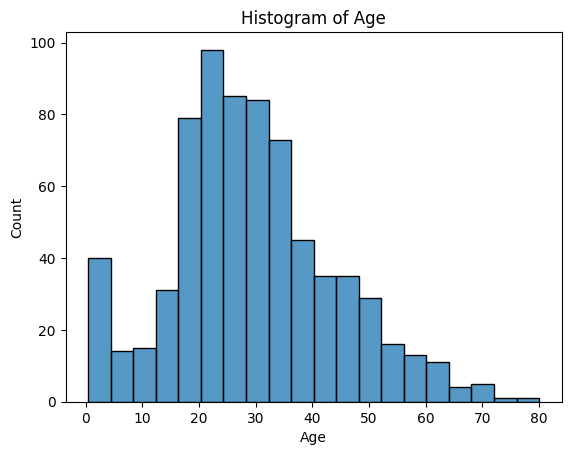

In [58]:
sns.histplot(df['Age'], bins=20, kde=False)
plt.title("Histogram of Age")
plt.show()

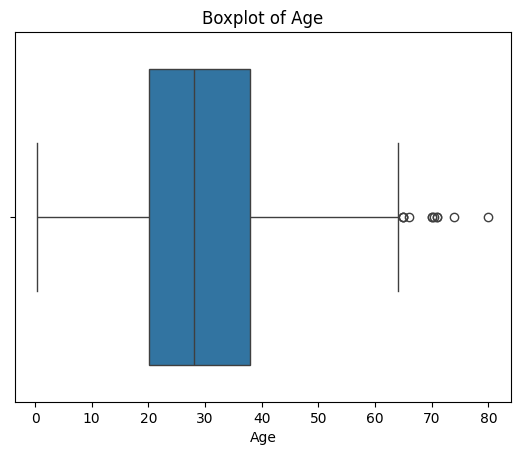

In [59]:
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()

## Categorical --- countplot, barplot(using value_counts),frequency table, Horizontal Bar Plot (For Many Categories), pie chart(Shows proportions and also good for small categories in a column)

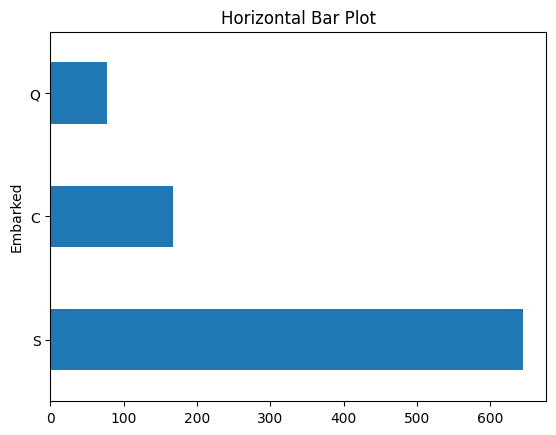

In [60]:
df['Embarked'].value_counts().plot(kind='barh')
plt.title("Horizontal Bar Plot")
plt.show()

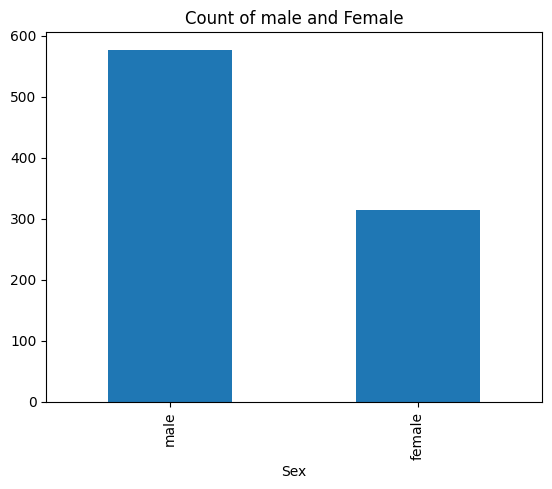

In [61]:
df['Sex'].value_counts().plot(kind='bar')
plt.title("Count of male and Female")
plt.show()

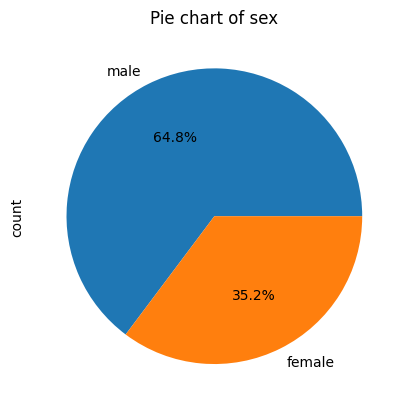

In [62]:
df['Sex'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("Pie chart of sex")
plt.show()

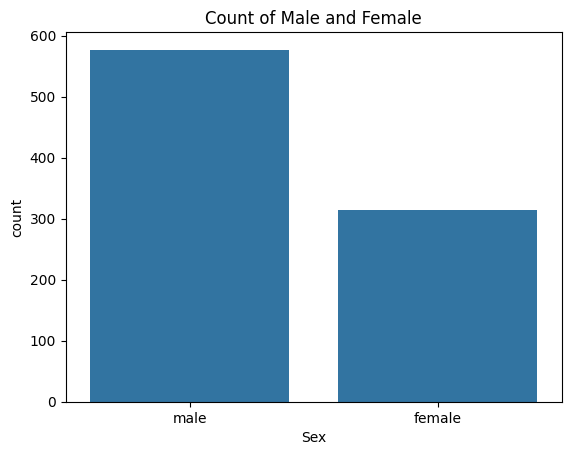

In [63]:
sns.countplot(x='Sex', data=df)
plt.title("Count of Male and Female")
plt.show()

In [64]:
df['Sex'].value_counts()
df['Sex'].value_counts(normalize=True)

,proportion
Sex,
male,0.647587
female,0.352413


## Bi-variate Analysis --- (Relationship between TWO variables)

## Numerical vs numerical -- Regression Plot, Scatter Plot

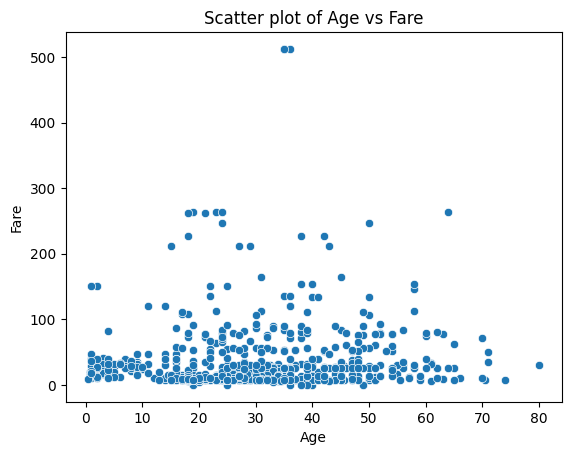

In [65]:
sns.scatterplot(x='Age',y='Fare',data = df)
plt.title('Scatter plot of Age vs Fare')
plt.show()

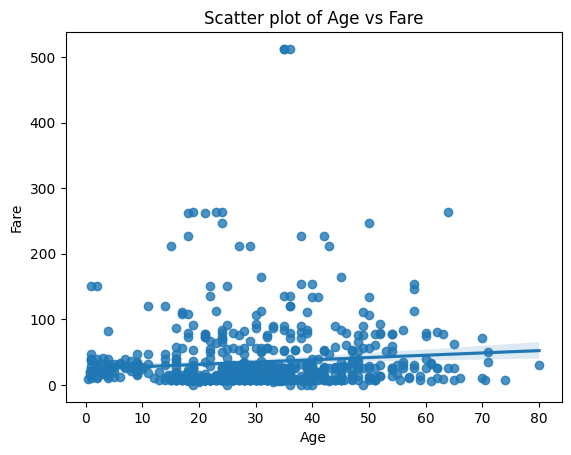

In [66]:
sns.regplot(x='Age',y='Fare',data = df)
plt.title('Scatter plot of Age vs Fare')
plt.show()

##Categorical Numerical-- boxplot(Compare distribution + median + outliers across categories) , barplot(mean comparison)

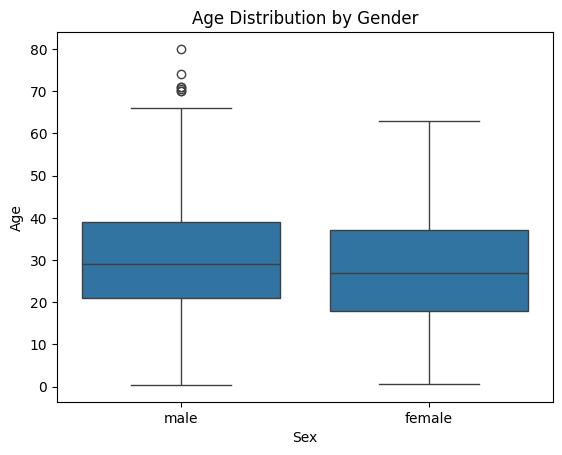

In [67]:
sns.boxplot(x='Sex', y='Age', data=df)
plt.title("Age Distribution by Gender")
plt.show()

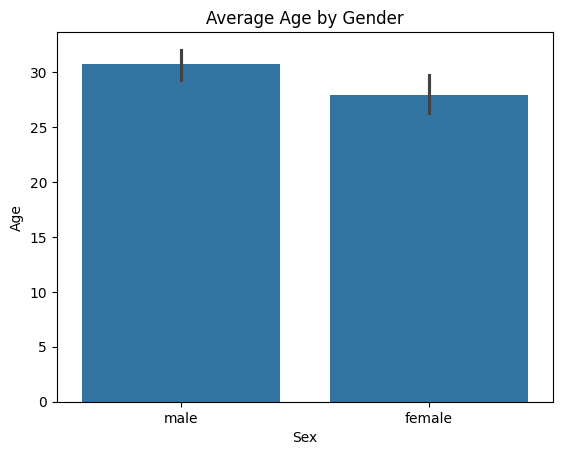

In [68]:
sns.barplot(x='Sex', y='Age', data=df)
plt.title("Average Age by Gender")
plt.show()

## categorical vs categorical --- countplot(with hue),Stacked Bar Plot,heatmap

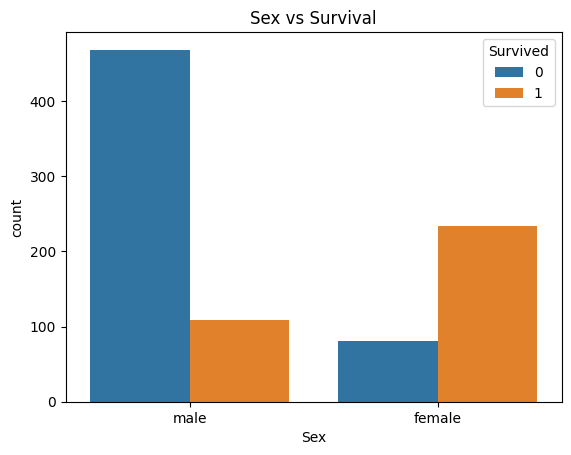

In [69]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Sex vs Survival")
plt.show()

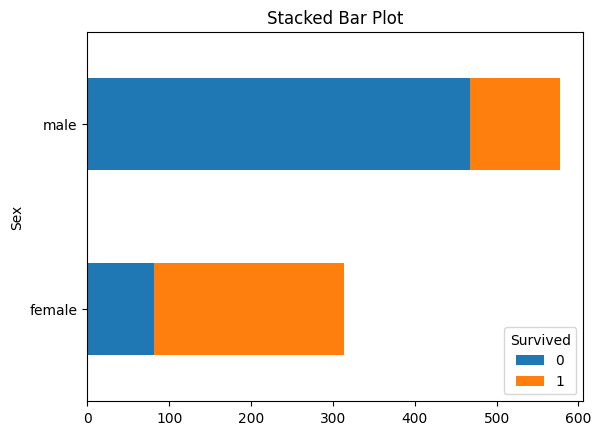

In [70]:
pd.crosstab(df['Sex'], df['Survived']).plot(kind='barh', stacked=True)
plt.title("Stacked Bar Plot")
plt.show()

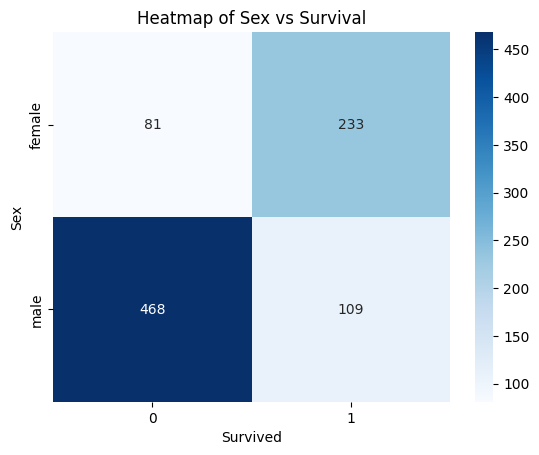

In [71]:
ct = pd.crosstab(df['Sex'], df['Survived'])

sns.heatmap(ct, annot=True, cmap='Blues', fmt='d')
plt.title("Heatmap of Sex vs Survival")
plt.show()

## Multivariate analysis ---pairplot , heatmap

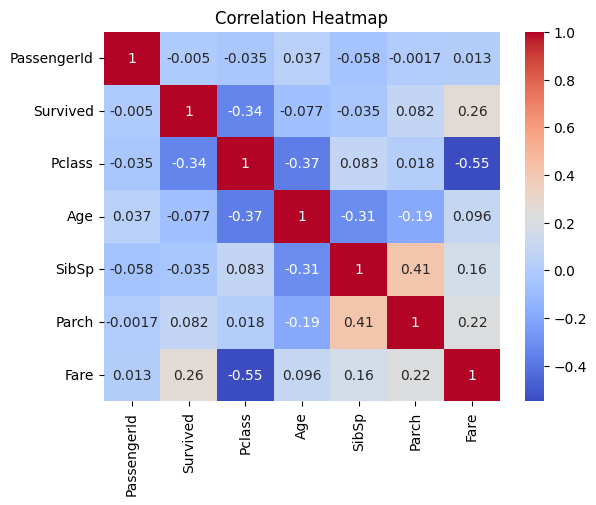

In [72]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

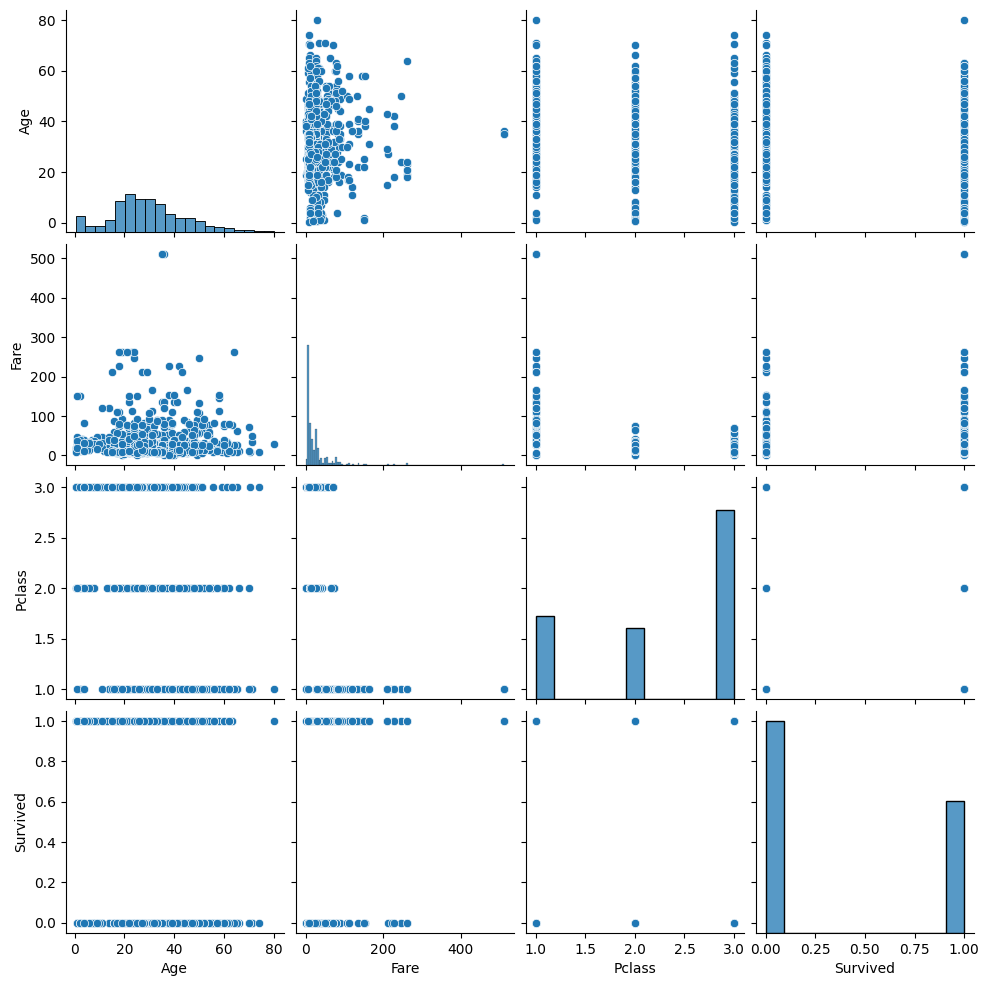

In [73]:
sns.pairplot(df[['Age','Fare','Pclass','Survived']])
plt.show()

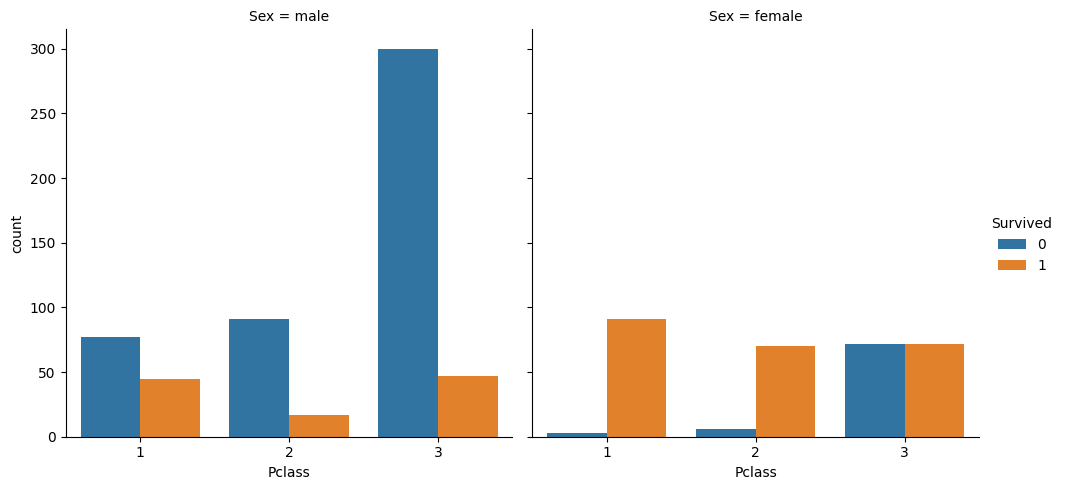

In [74]:
sns.catplot(x='Pclass', hue='Survived', col='Sex', data=df, kind='count')
plt.show()

In [77]:
df.to_csv("data.csv", index=False)